<a href="https://colab.research.google.com/github/ahmadizza/Noise-Robust-Sequence-Prediction-RNN-vs-LSTM/blob/main/Noise_Robust_Sequence_Prediction_RNN_vs_LSTM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Deep Learning**

Diberikan suatu data sequential yang berisi panjang `INPUT` (berisi angka 0 sampai 9) dan blank (diisi angka 10) yang menandakan terdapat noise dari data. Kolom target berisi angka-angka yang sama dengan `INPUT`. Buatlah model RNN dan LSTM untuk memprediksi angka-angka yang terdapat di dalam `INPUT`. Kemudian selidiki dan bandingkan training loss pada kedua model tersebut. Serta lakukan evaluasi kedua model tersebut dengan lima sampel yang berbeda. Selidiki pula magnitude dari bobot pada masing-masing model (opsional) pada saat proses training.

Contoh:
Misalkan kita punya `INPUT` dengan panjang 5 dan `BLANK` dengan panjang 3

* INPUT = [2,  9,  2,  0,  0]
* BLANK = [10, 10, 10]
* SAMPLE DATA = INPUT $\cup$ BLANK = [2,  9,  2,  0,  0, 10, 10, 10]

Maka targetnya adalah

TARGET = INPUT = [2,  9,  2,  0,  0]

CONTOH EVALUASI:

| Sample data | Target | Predicted | Correct |
|----------|----------|-----------|---------|
| [ 2  1  9  8  0  4  9  0  6  0 10 10 10 10 10 10 10 10 10 10 10 10 10 10 10 10 10 10 10 10]    | [2 1 9 **8** 0 4 9 0 6 0]   | [8 8 8 **8** 8 8 8 8 8 8] | 1/10 (10.0%)

Keterangan:

* Panjang input = Panjang target = 10
* Panjang blank = 20
* Panjang sample data = Panjang input + Panjang blank = 30




CATATAN:
Gunakan gradient clipping untuk menghindari exloding gradient dengan cara menambahkan `torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)` pada proses training.



---






# **Jawaban: Menggunakan Eksperimen Dua Arsitektur Model**

Dalam tugas ini, kami membandingkan performa model RNN dan LSTM menggunakan dua arsitektur `forward pass` yang berbeda. Tujuannya adalah untuk menguji secara spesifik dan membandingkan kemampuan model dalam menangani tugas **memori** **jangka pendek** dan **memori jangka panjang**.

**1. Model "Standar" (Prediksi dari Depan)**

Kode untuk model ini mengambil 10 output pertama dari sekuens:

`output = self.fc(rnn_out[:, :INPUT_LEN, :])`

*   **Tujuan:** Arsitektur ini dirancang untuk menguji memori jangka pendek. Model diminta untuk langsung **memprediksi 10 angka target segera setelah melihat 10 angka input pertama**. Tugas ini relatif lebih mudah karena jeda waktu antara input dan target sangat singkat. Model ini berfungsi sebagai baseline untuk melihat kemampuan dasar jaringan dalam mempelajari pola sekuens.
*   **Proses:** Model ini bekerja seperti menyalin langsung.
*   **Analogi:** Melihat 10 angka input pertama, misalnya `[2, 9, 2, ...]`, dan langsung saat itu juga diminta untuk menuliskan kembali 10 angka tersebut.


**2. Model "Memory" (Prediksi dari Belakang)**

Kode untuk model ini mengambil 10 output terakhir dari sekuens:

`output = self.fc(rnn_out[:, -INPUT_LEN:, :])`

*   **Tujuan:** Arsitektur ini secara spesifik dirancang untuk menguji memori jangka panjang. Model "**dipaksa" untuk memproses 10 angka input, kemudian melewati 20 token blank (noise), dan baru setelah itu harus mengingat kembali 10 angka input pertama untuk diprediksi**. Tugas ini jauh lebih sulit karena model harus mempertahankan informasinya dalam "ingatan" untuk periode yang lebih lama.
*   **Proses:** Model ini bekerja seperti tes ingatan dengan angka blank.
*   **Analogi:** Melihat 10 angka input `[2, 9, 2, ...]`, kemudian harus melihat 20 angka 10 yang tidak relevan (`[10, 10, 10, ...]`). Setelah semua angka 10 itu lewat, barulah ia diminta untuk mengingat kembali dan menuliskan 10 angka pertama tadi.







In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np
import random

# Set seed untuk reproduktifitas global
SEED = 123
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)

In [ ]:
# Tentukan device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device = {device}")

Device = cuda


In [ ]:
# Konstanta & Parameter
VOCAB_SIZE = 10  # Angka 0-9
BLANK_TOKEN = 10 # Token untuk blank
INPUT_LEN = 10   # Panjang sekuens target
BLANK_LEN = 20   # Jumlah blank yang akan disisipkan
TOTAL_LEN = INPUT_LEN + BLANK_LEN

# Parameter Model
HIDDEN_SIZE = 1024 # Ukuran hidden state
NUM_LAYERS = 4     # Jumlah lapisan RNN/LSTM
NUM_EPOCHS = 1000  # Jumlah epoch training
BATCH_SIZE = 64    # Ukuran batch
LEARNING_RATE = 0.001

## 1. GENERATE DATA

In [ ]:
def generate_batch():
    sequences = torch.randint(VOCAB_SIZE, (BATCH_SIZE, TOTAL_LEN), dtype=torch.long)
    blanks = torch.full((BATCH_SIZE, BLANK_LEN), VOCAB_SIZE, dtype=torch.long)
    inputs = torch.cat((sequences[:, :INPUT_LEN], blanks), dim=1)
    targets = sequences[:, :INPUT_LEN]
    return inputs.to(device), targets.to(device)

In [ ]:
inputs_1, targets_1 = generate_batch()
print("Input shape:", inputs_1.shape)
print("Target shape:", targets_1.shape)
print("Contoh Input[0]:\n", inputs_1[0])
print("Contoh Target[0]:\n", targets_1[0])

Input shape: torch.Size([64, 30])
Target shape: torch.Size([64, 10])
Contoh Input[0]:
 tensor([ 2,  9,  2,  0,  0,  2,  6,  7,  9,  4, 10, 10, 10, 10, 10, 10, 10, 10,
        10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10], device='cuda:0')
Contoh Target[0]:
 tensor([2, 9, 2, 0, 0, 2, 6, 7, 9, 4], device='cuda:0')


## 2. DEFINE MODEL RNN & LSTM

### Model 1: "Standar" (Prediksi dari Depan)

Kode untuk model ini mengambil 10 output pertama dari sekuens:

`output = self.fc(rnn_out[:, :INPUT_LEN, :])`

***Memprediksi 10 angka target segera setelah melihat 10 angka input pertama**.

#### Model RNN

In [ ]:
class SimpleRNN_Standard(nn.Module):
    def __init__(self, hidden_size, num_layers):
        super(SimpleRNN_Standard, self).__init__()
        self.model_type = "RNN_Standard"
        self.embedding = nn.Embedding(VOCAB_SIZE + 1, hidden_size)
        self.rnn = nn.RNN(hidden_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, VOCAB_SIZE)
    def forward(self, x):
        embedded = self.embedding(x)
        rnn_out, _ = self.rnn(embedded)
        # Mengambil 10 output PERTAMA
        output = self.fc(rnn_out[:, :INPUT_LEN, :])
        return output

#### Model LSTM

In [ ]:
class SimpleLSTM_Standard(nn.Module):
    def __init__(self, hidden_size, num_layers):
        super(SimpleLSTM_Standard, self).__init__()
        self.model_type = "LSTM_Standard"
        self.embedding = nn.Embedding(VOCAB_SIZE + 1, hidden_size)
        self.lstm = nn.LSTM(hidden_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, VOCAB_SIZE)
    def forward(self, x):
        embedded = self.embedding(x)
        lstm_out, _ = self.lstm(embedded)
        # Mengambil 10 output PERTAMA
        output = self.fc(lstm_out[:, :INPUT_LEN, :])
        return output

### Model 2: "Memory" (Prediksi dari Belakang)

Kode untuk model ini mengambil 10 output terakhir dari sekuens:

`output = self.fc(rnn_out[:, -INPUT_LEN:, :])`

**Model** "**dipaksa" untuk memproses 10 angka input, kemudian melewati 20 token blank (noise), dan baru setelah itu harus mengingat kembali 10 angka input pertama untuk diprediksi**.

#### Model RNN

In [ ]:
class SimpleRNN(nn.Module):
    def __init__(self, hidden_size, num_layers):
        super(SimpleRNN, self).__init__()
        self.model_type = "RNN"
        self.embedding = nn.Embedding(VOCAB_SIZE + 1, hidden_size)
        self.rnn = nn.RNN(hidden_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, VOCAB_SIZE)

    def forward(self, x):
        embedded = self.embedding(x)
        rnn_out, _ = self.rnn(embedded)
        output = self.fc(rnn_out[:, -INPUT_LEN:, :])
        return output

#### Model LSTM

In [ ]:
class SimpleLSTM(nn.Module):
    def __init__(self, hidden_size, num_layers):
        super(SimpleLSTM, self).__init__()
        self.model_type = "LSTM"
        self.embedding = nn.Embedding(VOCAB_SIZE + 1, hidden_size)
        self.lstm = nn.LSTM(hidden_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, VOCAB_SIZE)

    def forward(self, x):
        embedded = self.embedding(x)
        lstm_out, _ = self.lstm(embedded)
        output = self.fc(lstm_out[:, -INPUT_LEN:, :])
        return output

## 3. PROSES TRAINING

In [ ]:
def train_model(model, data_generator):
    print(f"\n--- Training Model {model.model_type} ---")
    model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
    criterion = nn.CrossEntropyLoss()

    loss_history = []
    grad_magnitude_history = []

    for epoch in range(NUM_EPOCHS):
        model.train()
        optimizer.zero_grad()
        inputs, targets = data_generator()
        outputs = model(inputs)
        loss = criterion(outputs.reshape(-1, VOCAB_SIZE), targets.reshape(-1))
        loss.backward()

        # Hitung magnitudo gradien sebelum clipping
        total_norm = 0
        for p in model.parameters():
            if p.grad is not None:
                param_norm = p.grad.detach().data.norm(2)
                total_norm += param_norm.item() ** 2
        total_norm = total_norm ** 0.5
        grad_magnitude_history.append(total_norm)

        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        loss_history.append(loss.item())

        if (epoch + 1) % 5 == 0:
            print(f"Epoch [{epoch+1}/{NUM_EPOCHS}], Loss: {loss.item():.4f}, Grad Mag: {total_norm:.4f}")

    print(f"Training selesai untuk model {model.model_type}")
    return loss_history, grad_magnitude_history

### Model 1: "Standar" (Prediksi dari Depan)

In [ ]:
# Menjalankan Training untuk Model "Standar"
print("\n" + "="*50 + "\nEKSPERIMEN 1: Model 'Standar' (Prediksi dari Depan)\n" + "="*50)
rnn_model_std = SimpleRNN_Standard(HIDDEN_SIZE, NUM_LAYERS).to(device)
lstm_model_std = SimpleLSTM_Standard(HIDDEN_SIZE, NUM_LAYERS).to(device)
rnn_loss_std, rnn_grads_std = train_model(rnn_model_std, generate_batch)
lstm_loss_std, lstm_grads_std = train_model(lstm_model_std, generate_batch)


EKSPERIMEN 1: Model 'Standar' (Prediksi dari Depan)

--- Training Model RNN_Standard ---
Epoch [5/1000], Loss: 0.0016, Grad Mag: 0.0103
Epoch [10/1000], Loss: 0.0001, Grad Mag: 0.0008
Epoch [15/1000], Loss: 0.0000, Grad Mag: 0.0008
Epoch [20/1000], Loss: 0.0000, Grad Mag: 0.0002
Epoch [25/1000], Loss: 0.0000, Grad Mag: 0.0002
Epoch [30/1000], Loss: 0.0000, Grad Mag: 0.0002
Epoch [35/1000], Loss: 0.0000, Grad Mag: 0.0001
Epoch [40/1000], Loss: 0.0000, Grad Mag: 0.0001
Epoch [45/1000], Loss: 0.0000, Grad Mag: 0.0001
Epoch [50/1000], Loss: 0.0000, Grad Mag: 0.0001
Epoch [55/1000], Loss: 0.0000, Grad Mag: 0.0001
Epoch [60/1000], Loss: 0.0000, Grad Mag: 0.0000
Epoch [65/1000], Loss: 0.0000, Grad Mag: 0.0000
Epoch [70/1000], Loss: 0.0000, Grad Mag: 0.0000
Epoch [75/1000], Loss: 0.0000, Grad Mag: 0.0000
Epoch [80/1000], Loss: 0.0000, Grad Mag: 0.0000
Epoch [85/1000], Loss: 0.0000, Grad Mag: 0.0000
Epoch [90/1000], Loss: 0.0000, Grad Mag: 0.0000
Epoch [95/1000], Loss: 0.0000, Grad Mag: 0.0000

### Model 2: "Memory" (Prediksi dari Belakang)

In [ ]:
# Menjalankan Training untuk Model "Memory"
print("\n" + "="*50 + "\nEKSPERIMEN 2: Model 'Memory' (Prediksi dari Belakang)\n" + "="*50)
rnn_model_1 = SimpleRNN(HIDDEN_SIZE, NUM_LAYERS).to(device)
lstm_model_1 = SimpleLSTM(HIDDEN_SIZE, NUM_LAYERS).to(device)
rnn_loss_1, rnn_grads_1 = train_model(rnn_model_1, generate_batch)
lstm_loss_1, lstm_grads_1 = train_model(lstm_model_1, generate_batch)


EKSPERIMEN 2: Model 'Memory' (Prediksi dari Belakang)

--- Training Model RNN ---
Epoch [5/1000], Loss: 3.0269, Grad Mag: 7.4036
Epoch [10/1000], Loss: 2.5512, Grad Mag: 6.5490
Epoch [15/1000], Loss: 2.3314, Grad Mag: 2.3031
Epoch [20/1000], Loss: 2.3361, Grad Mag: 2.6448
Epoch [25/1000], Loss: 2.3392, Grad Mag: 2.8335
Epoch [30/1000], Loss: 2.3220, Grad Mag: 2.1709
Epoch [35/1000], Loss: 2.3158, Grad Mag: 2.0341
Epoch [40/1000], Loss: 2.3311, Grad Mag: 2.5720
Epoch [45/1000], Loss: 2.3243, Grad Mag: 2.3120
Epoch [50/1000], Loss: 2.3148, Grad Mag: 1.9939
Epoch [55/1000], Loss: 2.3323, Grad Mag: 2.5527
Epoch [60/1000], Loss: 2.3446, Grad Mag: 3.1114
Epoch [65/1000], Loss: 2.3303, Grad Mag: 2.5004
Epoch [70/1000], Loss: 2.3581, Grad Mag: 3.3899
Epoch [75/1000], Loss: 2.3453, Grad Mag: 3.2086
Epoch [80/1000], Loss: 2.3470, Grad Mag: 3.2310
Epoch [85/1000], Loss: 2.3230, Grad Mag: 2.2077
Epoch [90/1000], Loss: 2.3218, Grad Mag: 2.1309
Epoch [95/1000], Loss: 2.3352, Grad Mag: 2.6560
Epoch 

## 4. PLOT TRAINING LOSS RNN VS LSTM

In [ ]:
def plot_loss(rnn_loss, lstm_loss):
    plt.figure(figsize=(10, 5))
    plt.plot(rnn_loss, label='RNN Loss', color='salmon')
    plt.plot(lstm_loss, label='LSTM Loss', color='skyblue')
    plt.title(f'Perbandingan Training Loss: {title_suffix}', fontsize=16)
    plt.xlabel('Epoch'); plt.ylabel('Cross-Entropy Loss'); plt.legend()
    plt.grid(True); plt.show()

### Model 1: "Standar" (Prediksi dari Depan)

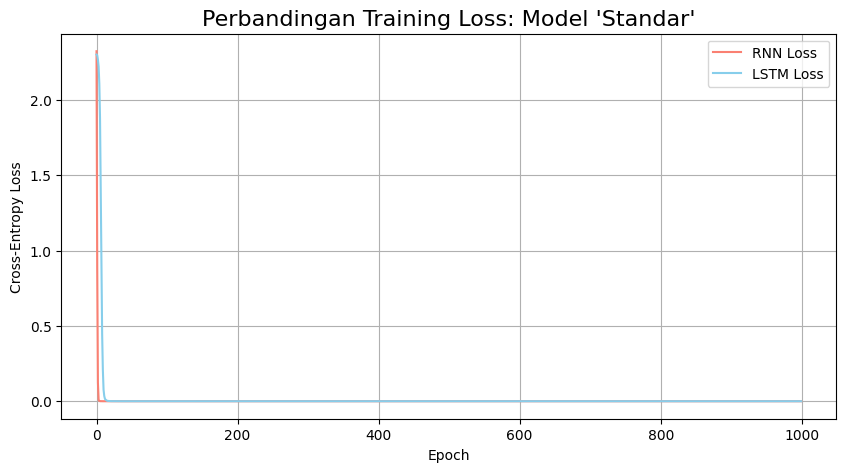

In [ ]:
plot_loss(rnn_loss_std, lstm_loss_std, "Model 'Standar")

Pada plot Perbandingan Training Loss: Model 'Standar' menunjukkan bahwa tugas menyalin langsung sangat mudah dilakukan oleh kedua model. Kedua model (RNN dan LSTM) turun secara drastis ke nilai mendekati nol dalam beberapa epoch pertama dan stagnan. Ini berarti kedua arsitektur model dapat dengan cepat dan sempurna mempelajari pola untuk tugas yang sederhana seperti ini.

### Model 2: "Memory" (Prediksi dari Belakang)

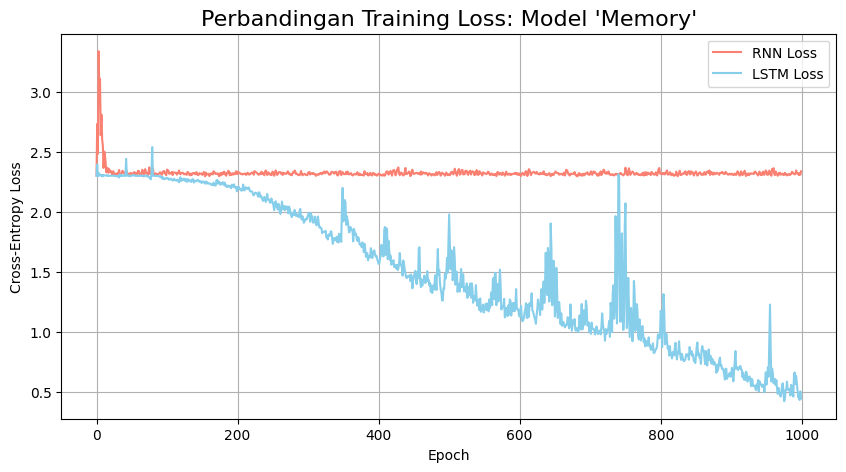

In [ ]:
plot_loss(rnn_loss_1, lstm_loss_1, "Model 'Memory'")

 Plot Perbandingan Training Loss: Model 'Memory' menunjukkan perbedaan kinerja yang drastis daripada arsitektur sebelumnya.

**RNN Loss:**

*   Pada epoch pertama terdapat lonjakan loss yang sangat tinggi (hampir 6.0). Ini terjadi karena model belum benar-benar menangkap inisialisasi bobot acak dari input data , sehingga model memberikan prediksi yang salah.
*   Setelah beberapa epoch, loss menurun dan stagnan di angka 2.3. Ini menunjukkan bahwa model gagal total untuk belajar karena masalah vanishing gradient.

**LSTM Loss:**

*   Loss turun secara konsisten seiring bertambahnya epoch, tapi fluktuatif. Fluktuatif di sini sangat wajar terjadi karena setiap epoch menggunakan batch data acak yang baru.
*   LSTM berhasil mempelajari pola dalam data.




## 5. EVALUASI MODELS

In [ ]:
def evaluate_models(rnn_model, lstm_model, data_generator, title_suffix, num_samples=5):
    print(f"\n--- Evaluasi Model: {title_suffix} ---")
    rnn_model.eval(); lstm_model.eval()
    with torch.no_grad():
        for i in range(num_samples):
            print(f"\n--- Sampel {i+1} ---")
            inputs, targets = data_generator()
            input_sample, target_sample = inputs[0:1], targets[0]
            rnn_pred = torch.argmax(rnn_model(input_sample), dim=2).squeeze()
            lstm_pred = torch.argmax(lstm_model(input_sample), dim=2).squeeze()
            rnn_correct = (rnn_pred == target_sample).sum().item()
            lstm_correct = (lstm_pred == target_sample).sum().item()

            print(f"Target      : {target_sample.cpu().numpy().tolist()}")
            print(f"RNN Prediksi: {rnn_pred.cpu().numpy().tolist()} (Correct: {rnn_correct/INPUT_LEN:.1%})")
            print(f"LSTM Prediksi: {lstm_pred.cpu().numpy().tolist()} (Correct: {lstm_correct/INPUT_LEN:.1%})")

### Model 1: "Standar" (Prediksi dari Depan)

In [ ]:
evaluate_models(rnn_model_std, lstm_model_std, generate_batch, "Model 'Standar")


--- Evaluasi Model: Model 'Standar ---

--- Sampel 1 ---
Target      : [6, 3, 4, 4, 6, 0, 6, 3, 2, 8]
RNN Prediksi: [6, 3, 4, 4, 6, 0, 6, 3, 2, 8] (Correct: 100.0%)
LSTM Prediksi: [6, 3, 4, 4, 6, 0, 6, 3, 2, 8] (Correct: 100.0%)

--- Sampel 2 ---
Target      : [2, 0, 8, 9, 0, 2, 3, 5, 8, 0]
RNN Prediksi: [2, 0, 8, 9, 0, 2, 3, 5, 8, 0] (Correct: 100.0%)
LSTM Prediksi: [2, 0, 8, 9, 0, 2, 3, 5, 8, 0] (Correct: 100.0%)

--- Sampel 3 ---
Target      : [5, 0, 6, 0, 1, 5, 7, 7, 2, 8]
RNN Prediksi: [5, 0, 6, 0, 1, 5, 7, 7, 2, 8] (Correct: 100.0%)
LSTM Prediksi: [5, 0, 6, 0, 1, 5, 7, 7, 2, 8] (Correct: 100.0%)

--- Sampel 4 ---
Target      : [2, 7, 3, 7, 9, 5, 1, 5, 8, 0]
RNN Prediksi: [2, 7, 3, 7, 9, 5, 1, 5, 8, 0] (Correct: 100.0%)
LSTM Prediksi: [2, 7, 3, 7, 9, 5, 1, 5, 8, 0] (Correct: 100.0%)

--- Sampel 5 ---
Target      : [2, 4, 2, 1, 4, 5, 4, 5, 2, 3]
RNN Prediksi: [2, 4, 2, 1, 4, 5, 4, 5, 2, 3] (Correct: 100.0%)
LSTM Prediksi: [2, 4, 2, 1, 4, 5, 4, 5, 2, 3] (Correct: 100.0%)


### Model 2: "Memory" (Prediksi dari Belakang)

In [ ]:
# Menjalankan Evaluasi Model 2: "Memory" (Mengingat)
evaluate_models(rnn_model_1, lstm_model_1, generate_batch, "Model 'Memory'")


--- Evaluasi Model: Model 'Memory' ---

--- Sampel 1 ---
Target      : [1, 6, 8, 3, 7, 3, 8, 0, 3, 4]
RNN Prediksi: [3, 3, 3, 3, 3, 3, 3, 3, 3, 3] (Correct: 30.0%)
LSTM Prediksi: [1, 6, 8, 3, 7, 3, 8, 0, 3, 4] (Correct: 100.0%)

--- Sampel 2 ---
Target      : [2, 8, 2, 5, 9, 7, 6, 9, 2, 1]
RNN Prediksi: [3, 3, 3, 3, 3, 3, 3, 3, 3, 3] (Correct: 0.0%)
LSTM Prediksi: [2, 8, 2, 5, 9, 2, 7, 9, 2, 1] (Correct: 80.0%)

--- Sampel 3 ---
Target      : [1, 4, 8, 0, 7, 9, 4, 4, 2, 3]
RNN Prediksi: [3, 3, 3, 3, 3, 3, 3, 3, 3, 3] (Correct: 10.0%)
LSTM Prediksi: [1, 4, 8, 1, 7, 9, 4, 4, 2, 3] (Correct: 90.0%)

--- Sampel 4 ---
Target      : [3, 2, 5, 9, 5, 8, 9, 8, 1, 1]
RNN Prediksi: [3, 3, 3, 3, 3, 3, 3, 3, 3, 3] (Correct: 10.0%)
LSTM Prediksi: [3, 2, 5, 9, 5, 8, 9, 8, 1, 1] (Correct: 100.0%)

--- Sampel 5 ---
Target      : [6, 6, 1, 7, 6, 3, 0, 3, 7, 5]
RNN Prediksi: [3, 3, 3, 3, 3, 3, 3, 3, 3, 3] (Correct: 20.0%)
LSTM Prediksi: [6, 6, 1, 7, 6, 3, 0, 3, 7, 5] (Correct: 100.0%)


## 6. Gradient Magnitude RNN vs LSTM (Opsional)

In [ ]:
def plot_gradients(rnn_grads, lstm_grads, title_suffix):
    plt.figure(figsize=(10, 5))
    plt.plot(rnn_grads, label='RNN Gradients', color='salmon')
    plt.plot(lstm_grads, label='LSTM Gradients', color='skyblue')
    plt.title(f'Perbandingan Magnitudo Gradien: {title_suffix}', fontsize=16)
    plt.xlabel('Epoch'); plt.ylabel('Total Gradient Norm (log scale)'); plt.legend()
    plt.yscale('log') # Skala log sangat penting di sini
    plt.grid(True); plt.show()

### Model 1: "Standar" (Prediksi dari Depan)

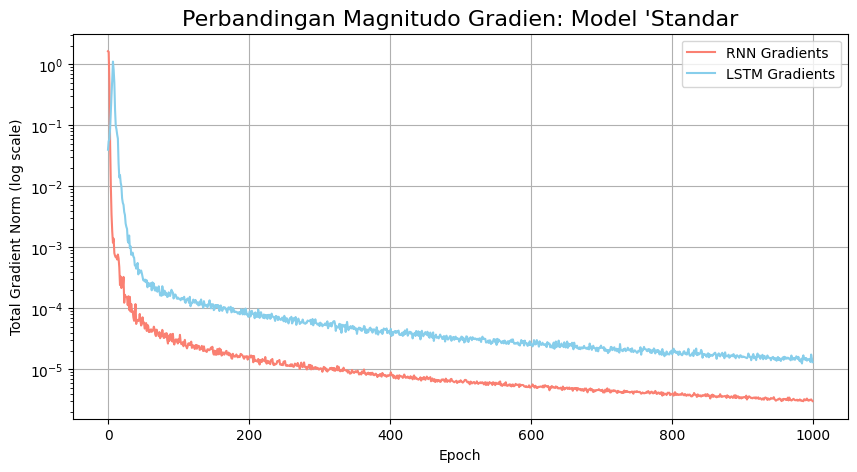

In [ ]:
plot_gradients(rnn_grads_std, lstm_grads_std, "Model 'Standar")

Pada plot Magnitudo Gradien Model Standar ini terlihat terdapat lonjakan awal yang sangat tinggi, gradien RNN dan LSTM menuju nilai yang sangat kecil. Dalam arsitektur model ini terlihat bahwa model telah berhasil. Ketika error sudah mendekati nol, maka gradien yang dihasilkan juga menjadi sangat kecil.

### Model 2: "Memory" (Prediksi dari Belakang)

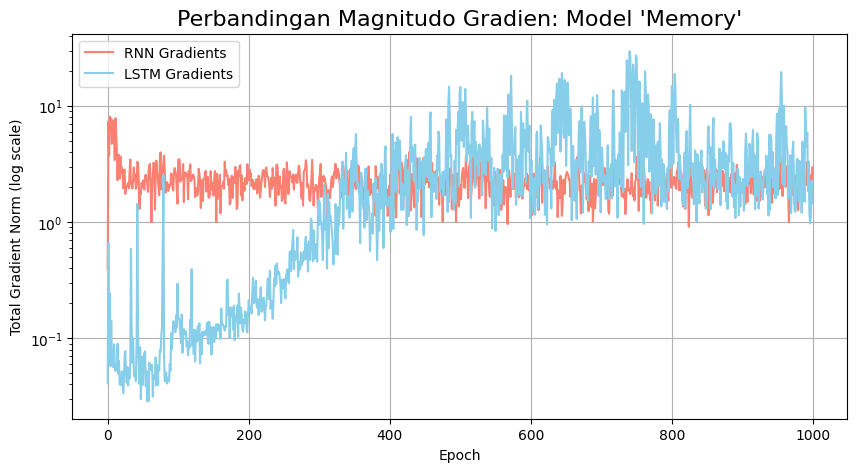

In [ ]:
plot_gradients(rnn_grads_1, lstm_grads_1, "Model 'Memory'" )

Pada tugas yang sulit, plot Perbandingan Magnitudo Gradien Model Memory menunjukkan penyebab perbedaan performa.

**RNN Gradien:**

*   Setelah lonjakan awal, gradien RNN cenderung stabil dari awal sampai akhir training.
*   Magnitudo gradien yang stabil namun tidak mengecil menunjukkan model mengalami kesulitan belajar, dan sinyal terlalu lemah untuk menghasilkan perbaikan pada loss. Ini merupakam masalah dari vanishing gradient.

**LSTM Gradien:**

*   Awalnya kecil (< 0.1), lalu naik secara bertahap hingga mendekati nilai yang lebih tinggi (sekitar 10).
*   Ini menunjukkan LSTM belajar lebih baik, meskipun ada fluktuasi tinggi yang bisa disebabkan oleh ketidakstabilan gradien saat mendekati konvergensi.

## 7. Komentar

Kami tidak hanya membandingkan arsitektur RNN vs. LSTM, tetapi juga melihat kedua arsitektur tersebut menangani tugas prediksi dari depan (Model 'Standar') dan prediksi dari belakang (Model 'Memory').

### **Model 'Standar' (Predeksi dari Depan)**

*   **Model "Standar"** hanya perlu menyalin 10 angka input pertama ke 10 output pertama. Ini adalah tugas ketergantungan sekuens jangka pendek karena jarak antara input dan target sangat dekat.
*   **Performa:** Hasilnya menunjukkan bahwa kedua model, baik RNN maupun LSTM, berhasil menyelesaikan tugas ini dengan sempurna.
*   **Bukti:**
  *   **Evaluasi:** Hasil evaluasi menunjukkan akurasi 100% untuk kedua model.
  *   **Training Loss:** Plot loss menunjukkan kedua kurva turun ke nol hampir secara instan, menandakan error berhasil diminimalkan.
  *   **Magnitudo Gradien:** Plot gradien menurun ke nilai sangat kecil pada kasus ini bukanlah tanda kegagalan, melainkan konfirmasi bahwa model telah konvergen dan tidak ada lagi error yang signifikan untuk dikoreksi.









### **Model 'Memory' (Predeksi dari Belakang)**


*   **Model "Memory"** harus mengingat 10 angka pertama setelah melewati 20 token blank. Ini adalah tugas ketergantungan jangka panjang yang jauh lebih sulit.
*   **Performa:** Model RNN gagal total, sementara model LSTM berhasil dengan baik.
*   **Bukti:**

  **1. Kegagalan RNN:**

  *   **Training Loss:** Model RNN gagal total dalam mempelajari tugas ini. Kurva loss-nya langsung stagnan setelah beberapa epoch awal, menunjukkan proses pembelajaran berhenti.
  *   Dapat dilihat dari **hasil evaluasi**, hanya dapat akurasi 0-10%, di mana prediksi RNN hanya berupa pengulangan satu angka secara terus-menurus ([3, 3, 3, ...])
  *   **Kegagalan** ini disebabkan oleh masalah utama Model RNN, yaitu vanishing gradient. Pada sekuens yang panjang, sinyal error menjadi terlalu lemah untuk bisa meneruskan bobot di awal sekuens. Ini dapat dilihat dari **plot magnitudo gradien**, di mana gradien RNN terlihat stagnan yang tidak efektif, menandakan hilangnya sinyal dari proses pembelajaran.

  **2. Keberhasilan LSTM:**
   *   **Training Loss:** Model LSTM menunjukkan kinerja yang sangat baik. Kurva loss-nya terus menurun secara konsisten, meskipun sedikit fluktuatif karena penggunaan batch data acak di setiap epoch.
  *   **Hasil evaluasi** sangat bagus, dengan akurasi mencapai 80-90%, hanya salah 2-3 angka saja, membuktikan kemampuannya untuk mengingat sekuens asli dan mengabaikan noise.
  *   **Keberhasil LSTM** dikarenakan LSTM dirancang khusus untuk mengatasi vanishing gradient. Plot magnitudo gradiennya yang sehat dan dinamis menunjukkan bahwa sinyal pembelajaran berhasil dialirkan secara efektif, yang memungkinkan model untuk terus belajar.
















### **Masalah Exploding Gradient:**

  Masalah exploding gradient (gradien yang meledak) tidak terlihat pada plot karena tugas ini menggunakan gradient clipping, yang secara efektif mencegah gradien tumbuh secara tak terkendali.

  Terletak pada fungsi `train_model`, tepatnya pada baris
```
torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
```

### **Perbandingan dan Kesimpulan**

Hasil dari Tugas UAS Deep Learning ini memberikan bukti  bahwa:



*   RNN hanya mampu menangani ketergantungan jangka pendek. RNN berhasil pada tugas "Standar" tetapi gagal total pada tugas "Memory", membuktikan kelemahannya dalam mengingat informasi dalam rentang waktu yang panjang
*   Sebaliknya, LSTM, berhasil baik pada tugas jangka "Standar" pendek maupun jangka panjang "Memory". Menunjukkan bahwa berkat arsitekturnya yang lebih canggih, mampu menyelesaikan tugas dengan sangat baik dan menjadi pilihan yang jauh lebih baik.

